⚡ Running on: cuda


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Training ViT Canopy Segmenter for 15 Epochs...
Epoch [01/15] | Segmentation BCE Loss: 0.5977
Epoch [03/15] | Segmentation BCE Loss: 0.4527
Epoch [06/15] | Segmentation BCE Loss: 0.3730
Epoch [09/15] | Segmentation BCE Loss: 0.3381
Epoch [12/15] | Segmentation BCE Loss: 0.2991
Epoch [15/15] | Segmentation BCE Loss: 0.2816
Training complete!


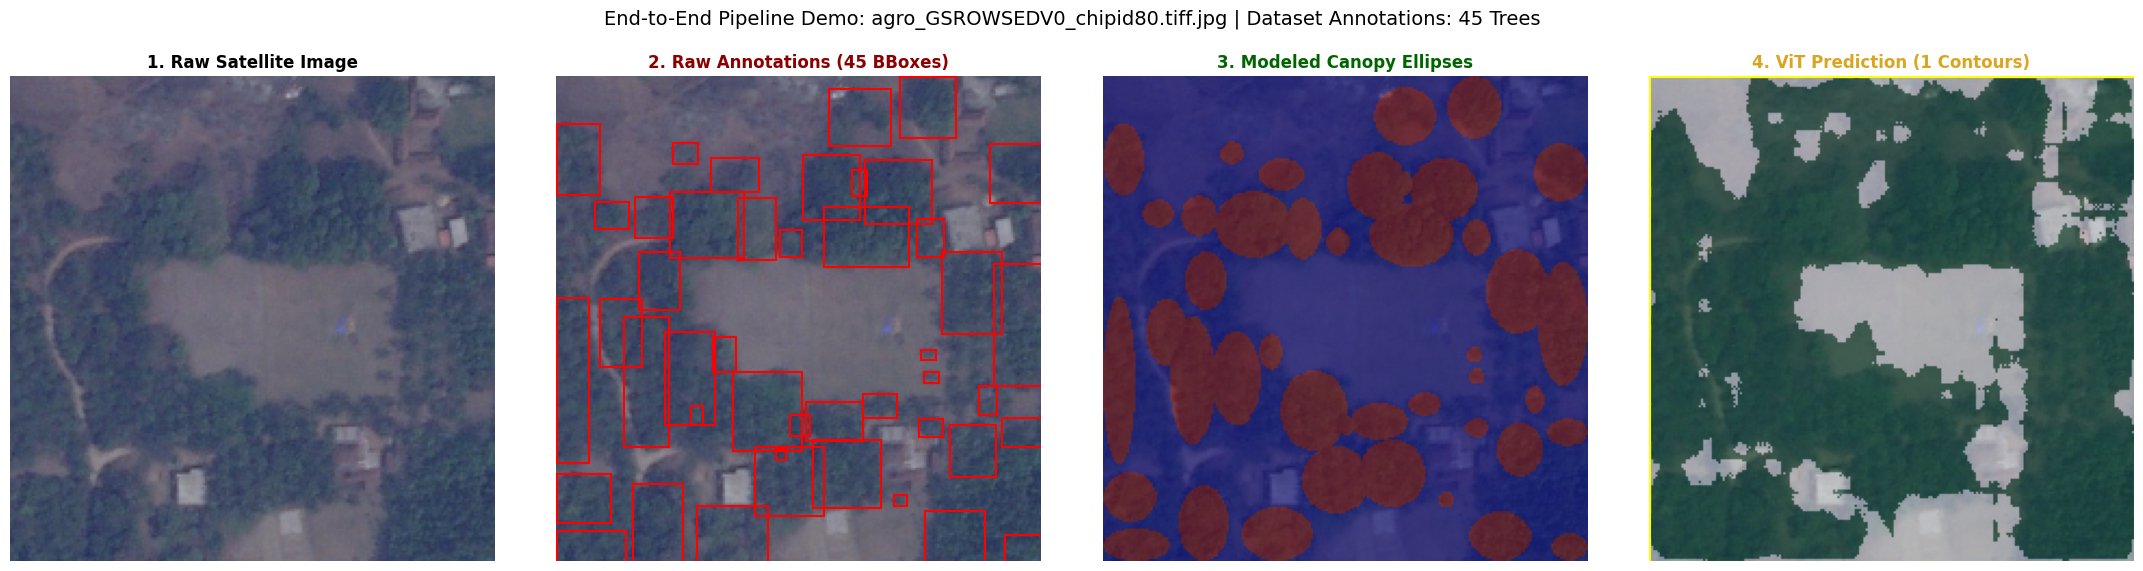

In [7]:
# ==============================================================================
# ViT ENCODER + CONV DECODER: COMPLETE 4-STAGE PIPELINE (15 EPOCHS)
# Shows Raw Image -> Original BBoxes -> Modeled Ellipses -> ViT Prediction
# ==============================================================================
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import Dataset, DataLoader
from transformers import ViTModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Running on: {device}")

# ------------------------------------------------------------------------------
# 1. PYTORCH DATALOADER: Bounding Boxes -> Crown Ellipses
# ------------------------------------------------------------------------------
class CanopySegmentationDataset(Dataset):
    def __init__(self, csv_file, img_dir, target_size=(224, 224), max_samples=400):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.target_size = target_size
        self.unique_images = self.df['image_path'].unique()[:max_samples]
        self.grouped = self.df.groupby('image_path')

    def __len__(self):
        return len(self.unique_images)

    def __getitem__(self, idx):
        img_name = self.unique_images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # Load and resize image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_h, orig_w, _ = img.shape

        img_resized = cv2.resize(img, self.target_size).astype(np.float32) / 255.0
        img_tensor = torch.tensor(img_resized).permute(2, 0, 1) # (3, 224, 224)

        # Build binary canopy mask using filled ellipses for realistic crowns
        mask = np.zeros(self.target_size, dtype=np.float32)
        boxes = self.grouped.get_group(img_name)

        scale_x = self.target_size[0] / orig_w
        scale_y = self.target_size[1] / orig_h

        for _, row in boxes.iterrows():
            cx = int(((row['xmin'] + row['xmax']) / 2.0) * scale_x)
            cy = int(((row['ymin'] + row['ymax']) / 2.0) * scale_y)
            rx = max(3, int(((row['xmax'] - row['xmin']) / 2.0) * scale_x))
            ry = max(3, int(((row['ymax'] - row['ymin']) / 2.0) * scale_y))

            # Draw filled ellipse representing individual tree canopy
            cv2.ellipse(mask, (cx, cy), (rx, ry), 0, 0, 360, 1.0, -1)

        mask_tensor = torch.tensor(mask).unsqueeze(0) # (1, 224, 224)
        return img_tensor, mask_tensor, img_name

# ------------------------------------------------------------------------------
# 2. HYBRID MODEL: ViT Backbone + Custom ConvTranspose Decoder
# ------------------------------------------------------------------------------
class ViTCanopySegmenter(nn.Module):
    def __init__(self):
        super(ViTCanopySegmenter, self).__init__()
        self.encoder = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        for param in self.encoder.parameters():
            param.requires_grad = False

        # 4-Stage Convolutional Upsampling Decoder (14x14 -> 224x224)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(768, 256, kernel_size=4, stride=2, padding=1), # 14 -> 28
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 28 -> 56
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 56 -> 112
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 112 -> 224
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=1) # Logits
        )

    def forward(self, pixel_values):
        outputs = self.encoder(pixel_values=pixel_values)
        patch_embeddings = outputs.last_hidden_state[:, 1:, :] # (B, 196, 768)

        B, N, C = patch_embeddings.shape
        grid_size = int(np.sqrt(N))
        spatial_features = patch_embeddings.permute(0, 2, 1).reshape(B, C, grid_size, grid_size)

        logits = self.decoder(spatial_features)
        return logits

# ------------------------------------------------------------------------------
# 3. TRAINING LOOP: 15 Epochs
# ------------------------------------------------------------------------------
DATA_DIR = "/content/unified_dataset"
train_dataset = CanopySegmentationDataset(
    csv_file=os.path.join(DATA_DIR, "train.csv"),
    img_dir=os.path.join(DATA_DIR, "images"),
    max_samples=350
)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

model = ViTCanopySegmenter().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([3.0]).to(device))
optimizer = torch.optim.Adam(model.decoder.parameters(), lr=8e-4)

EPOCHS = 15
print("\nTraining ViT Canopy Segmenter for 15 Epochs...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, masks, _ in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Segmentation BCE Loss: {avg_loss:.4f}")

print("Training complete!")

# ------------------------------------------------------------------------------
# 4. VISUAL DEMO: The 4-Panel Masterpiece Pipeline
# ------------------------------------------------------------------------------
model.eval()
test_dataset = CanopySegmentationDataset(
    csv_file=os.path.join(DATA_DIR, "test.csv"),
    img_dir=os.path.join(DATA_DIR, "images"),
    max_samples=15
)
sample_img, sample_mask, sample_name = test_dataset[2]

# 1. Fetch raw bounding box coordinates for this test image
raw_boxes = test_dataset.grouped.get_group(sample_name)
orig_img_path = os.path.join(DATA_DIR, "images", sample_name)
orig_h, orig_w, _ = cv2.imread(orig_img_path).shape

scale_x = 224.0 / orig_w
scale_y = 224.0 / orig_h

# 2. Run ViT Inference
with torch.no_grad():
    logits = model(sample_img.unsqueeze(0).to(device))
    pred_prob = torch.sigmoid(logits).squeeze().cpu().numpy()

pred_binary = (pred_prob > 0.45).astype(np.uint8)

# 3. Contour extraction for predicted bounding boxes
contours, _ = cv2.findContours(pred_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
detected_boxes = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) > 15]

actual_box_count = len(raw_boxes)
pred_count = len(detected_boxes)

# 4. Plotting the 4 Panels Side-by-Side
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
orig_np = sample_img.permute(1, 2, 0).numpy()

# Panel 1: Raw Satellite Image
axes[0].imshow(orig_np)
axes[0].set_title("1. Raw Satellite Image", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Panel 2: Original Ground Truth Bounding Boxes (Rectangles)
axes[1].imshow(orig_np)
for _, row in raw_boxes.iterrows():
    bx = row['xmin'] * scale_x
    by = row['ymin'] * scale_y
    bw = (row['xmax'] - row['xmin']) * scale_x
    bh = (row['ymax'] - row['ymin']) * scale_y
    rect = patches.Rectangle((bx, by), bw, bh, linewidth=1.5, edgecolor='red', facecolor='none')
    axes[1].add_patch(rect)
axes[1].set_title(f"2. Raw Annotations ({actual_box_count} BBoxes)", fontsize=12, color='darkred', fontweight='bold')
axes[1].axis('off')

# Panel 3: Modeled Ground Truth Canopy Ellipses
axes[2].imshow(orig_np)
axes[2].imshow(sample_mask.squeeze().numpy(), cmap='jet', alpha=0.5)
axes[2].set_title("3. Modeled Canopy Ellipses", fontsize=12, color='darkgreen', fontweight='bold')
axes[2].axis('off')

# Panel 4: ViT + Decoder Prediction (Segmented Canopy + Extracted Boxes)
axes[3].imshow(orig_np)
axes[3].imshow(pred_binary, cmap='Greens', alpha=0.45)
for x, y, w, h in detected_boxes:
    rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='yellow', facecolor='none')
    axes[3].add_patch(rect)
axes[3].set_title(f"4. ViT Prediction ({pred_count} Contours)", fontsize=12, color='goldenrod', fontweight='bold')
axes[3].axis('off')

plt.suptitle(f"End-to-End Pipeline Demo: {sample_name} | Dataset Annotations: {actual_box_count} Trees", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()